# LC updated cal/val runs August 2026


In [1]:
# Install required packages
import pandas as pd
from pathlib import Path
import os                      
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

In [4]:
# Load observation discharge data into a dataframe
obs = pd.read_csv("../Data/Cal&Val/daily_discharge_0531.txt", sep="\t")

obs["Time"] = pd.to_datetime(obs["Time"])
obs = obs.set_index("Time")
print(obs.head())

            Shiplaw_Burn  Middle_Burn  Middle_Longcote  Kidston_Mill
Time                                                                
2011-03-22         0.016        0.012            0.025         0.942
2011-03-23         0.014        0.011            0.023         0.841
2011-03-24         0.012        0.010            0.022         0.760
2011-03-25         0.006        0.010            0.020         0.709
2011-03-26         0.004        0.009            0.020         0.667


In [5]:
# Load modelled discharge data
cal = pd.read_csv("../Data/Cal&Val/Eddleston_LC_calDetailedTS_M11.txt", sep="\\t")
cal["Time"] = pd.to_datetime(cal["Time"])
cal = cal.set_index("Time")

val = pd.read_csv("../Data/Cal&Val/Eddleston_LC_valDetailedTS_M11.txt", sep="\\t")
val["Time"] = pd.to_datetime(val["Time"])
val = val.set_index("Time")

/var/folders/6k/k4px0zc93gxbk1b2nnkh3gdr0000gn/T/ipykernel_34059/3230719358.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  cal = pd.read_csv("../Data/Cal&Val/Eddleston_LC_calDetailedTS_M11.txt", sep="\\t")
/var/folders/6k/k4px0zc93gxbk1b2nnkh3gdr0000gn/T/ipykernel_34059/3230719358.py:6: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  val = pd.read_csv("../Data/Cal&Val/Eddleston_LC_valDetailedTS_M11.txt", sep="\\t")


In [6]:
print(cal)

                     Shiplaw_Burn  Middle_Burn  Middle_Longcote  Kidston_Mill
Time                                                                         
2011-03-22 00:00:50      0.000000     0.000000         0.000000      0.000000
2011-03-23 00:00:50      0.017421     0.009732         0.063824      0.237469
2011-03-24 00:00:50      0.014834     0.011756         0.067051      0.282687
2011-03-25 00:00:50      0.013796     0.009765         0.059611      0.233796
2011-03-26 00:00:50      0.013334     0.008159         0.054311      0.204925
...                           ...          ...              ...           ...
2016-03-18 00:03:20      0.016967     0.012342         0.046767      0.233675
2016-03-19 00:03:20      0.016460     0.011518         0.044344      0.214990
2016-03-20 00:03:20      0.016320     0.011661         0.040567      0.208213
2016-03-21 00:03:20      0.016175     0.012455         0.038546      0.213934
2016-03-22 00:03:20      0.015592     0.009385         0.036970 

In [25]:
# Normalise data
for df in [obs, cal, val]:
    df.index = pd.to_datetime(df.index).normalize()

cal_norm = cal.copy().sort_index()
val_norm = val.copy().sort_index()

calibration = cal_norm.loc["2011-03-23":"2016-03-23"].copy()
validation = val_norm.loc["2016-03-23":"2020-03-05"].copy()

calibration = calibration.loc[calibration.index < pd.Timestamp("2016-03-23")]
validation = validation.loc[validation.index >= pd.Timestamp("2016-03-23")]

obs_cal = obs.loc["2011-03-23":"2016-03-23"]
obs_val = obs.loc["2016-03-23":"2020-03-05"]


# Merge data
merged_cal = pd.merge(
    obs_cal, calibration,
    left_index=True, right_index=True,
    how="inner", suffixes=("_obs", "_cal")
)

merged_val = pd.merge(
    obs_val, validation,
    left_index=True, right_index=True,
    how="inner", suffixes=("_obs", "_val")
)

## Statistics

### Calibration

In [ ]:
# r (correlation coefficient)

gauges = ["Shiplaw_Burn", "Middle_Burn", "Middle_Longcote", "Kidston_Mill"]
scenarios = ["cal"]

r_table = {}

for g in gauges:
    r_table[g] = {}
    for s in scenarios:
        mod_col = f"{g}_{s}"
        obs_col = f"{g}_obs"
        r_table[g][s] = merged_cal[mod_col].corr(merged_cal[obs_col])

# Convert to DataFrame
r_dfcal = pd.DataFrame(r_table).T
r_dfcal

,cal
Shiplaw_Burn,0.820713
Middle_Burn,0.788717
Middle_Longcote,0.851569
Kidston_Mill,0.888941


In [ ]:
# NSE 

def nse(sim, obs):
    sim = np.array(sim)
    obs = np.array(obs)
    return 1 - np.sum((sim - obs)**2) / np.sum((obs - obs.mean())**2)

nse_table = {}

for g in gauges:
    nse_table[g] = {}
    for s in scenarios:
        mod_col = f"{g}_{s}"
        obs_col = f"{g}_obs"
        nse_table[g][s] = nse(merged_cal[mod_col], merged_cal[obs_col])

nse_dfcal = pd.DataFrame(nse_table).T
nse_dfcal

,cal
Shiplaw_Burn,0.648603
Middle_Burn,0.507327
Middle_Longcote,0.709532
Kidston_Mill,0.698088


In [54]:
# PBIAS
def pbias(sim, obs):
    sim = np.array(sim)
    obs = np.array(obs)
    # PBIAS = 100 * sum(sim - obs) / sum(obs)
    return 100.0 * np.sum(sim - obs) / np.sum(obs)

# Calibration PBIAS
pbias_tablecal = {}
for g in gauges:
    pbias_tablecal[g] = {}
    mod_col = f"{g}_cal"
    obs_col = f"{g}_obs"
    pbias_tablecal[g]["cal"] = pbias(merged_cal[mod_col], merged_cal[obs_col])

pbias_dfcal = pd.DataFrame(pbias_tablecal).T
pbias_dfcal

,cal
Shiplaw_Burn,1.063072
Middle_Burn,-36.029786
Middle_Longcote,-8.564532
Kidston_Mill,-35.910730


### Validation

In [ ]:
# r coefficient
gauges = ["Shiplaw_Burn", "Middle_Burn", "Middle_Longcote", "Kidston_Mill"]
scenarios = ["val"]

r_tableval = {}

for g in gauges:
    r_tableval[g] = {}
    for s in scenarios:
        mod_col = f"{g}_{s}"
        obs_col = f"{g}_obs"
        r_tableval[g][s] = merged_val[mod_col].corr(merged_val[obs_col])

# Convert to DataFrame
r_dfval = pd.DataFrame(r_tableval).T
r_dfval

,val
Shiplaw_Burn,0.724139
Middle_Burn,0.648997
Middle_Longcote,0.726505
Kidston_Mill,0.823118


In [ ]:
# NSE
nse_tableval = {}

for g in gauges:
    nse_tableval[g] = {}
    for s in scenarios:
        mod_col = f"{g}_{s}"
        obs_col = f"{g}_obs"
        nse_tableval[g][s] = nse(merged_val[mod_col], merged_val[obs_col])

nse_dfval = pd.DataFrame(nse_tableval).T
nse_dfval

,val
Shiplaw_Burn,0.490014
Middle_Burn,0.272592
Middle_Longcote,0.516980
Kidston_Mill,0.557133


In [53]:
# PBIAS
pbias_tableval = {}
for g in gauges:
    pbias_tableval[g] = {}
    mod_col = f"{g}_val"
    obs_col = f"{g}_obs"
    pbias_tableval[g]["val"] = pbias(merged_val[mod_col], merged_val[obs_col])

pbias_dfval = pd.DataFrame(pbias_tableval).T
pbias_dfval


,val
Shiplaw_Burn,-19.190717
Middle_Burn,-53.580763
Middle_Longcote,11.245247
Kidston_Mill,-43.883768


## Combined stats tables

In [58]:
# rename columns first 
r_df_ren = r_df.rename(columns={col: 'r' for col in r_df.columns})
nse_df_ren = nse_df.rename(columns={col: 'NSE' for col in nse_df.columns})
pbias_df_ren = pbias_df.rename(columns={col: 'PBIAS' for col in pbias_df.columns})

stats_df = pd.concat([r_df_ren, nse_df_ren, pbias_df_ren], axis=1)
stats_df

# Calidation
r_dfcal_ren = r_dfcal.rename(columns={col: 'r' for col in r_dfcal.columns})
nse_dfcal_ren = nse_dfcal.rename(columns={col: 'NSE' for col in nse_dfcal.columns})
pbias_dfcal_ren = pbias_dfcal.rename(columns={col: 'PBIAS' for col in pbias_dfcal.columns})

stats_df_cal = pd.concat([r_dfcal_ren, nse_dfcal_ren, pbias_dfcal_ren], axis=1)
stats_df_cal


,r,NSE,PBIAS
Shiplaw_Burn,0.820713,0.648603,1.063072
Middle_Burn,0.788717,0.507327,-36.029786
Middle_Longcote,0.851569,0.709532,-8.564532
Kidston_Mill,0.888941,0.698088,-35.910730


In [56]:
# Validation
r_dfval_ren = r_dfval.rename(columns={col: 'r' for col in r_dfval.columns})
nse_dfval_ren = nse_dfval.rename(columns={col: 'NSE' for col in nse_dfval.columns})
pbias_dfval_ren = pbias_dfval.rename(columns={col: 'PBIAS' for col in pbias_dfval.columns})

stats_df_val = pd.concat([r_dfval_ren, nse_dfval_ren, pbias_dfval_ren], axis=1)
stats_df_val

,r,NSE,PBIAS
Shiplaw_Burn,0.724139,0.490014,-19.190717
Middle_Burn,0.648997,0.272592,-53.580763
Middle_Longcote,0.726505,0.516980,11.245247
Kidston_Mill,0.823118,0.557133,-43.883768


# Figures

## Monthly regimes

In [ ]:
# Compute monthly regimes
obs_regime = obs.groupby(obs.index.month).mean()
full = pd.concat([calibration, validation], axis=0).sort_index()
full_regime = full.groupby(full.index.month).mean()

month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

obs_regime.index = month_names
full_regime.index = month_names

In [60]:
def create_regime(df_name):
    return pd.DataFrame({
        "Modelled": full.groupby(full.index.month)[df_name].mean(),
        "Observed": obs.groupby(obs.index.month)[df_name].mean()
    })

In [61]:
regimes_SB = create_regime("Shiplaw_Burn")
regimes_MB = create_regime("Middle_Burn")
regimes_ML = create_regime("Middle_Longcote")
regimes_KM = create_regime("Kidston_Mill")

for df in [regimes_SB, regimes_MB, regimes_ML, regimes_KM]:
    df.index = month_names

## Plot full time-series for cal and val + monthly regimes

In [65]:
# Convert daily to monthly mean
observations_monthly = obs.resample("ME").mean()
calandval_monthly = full.resample("ME").mean()

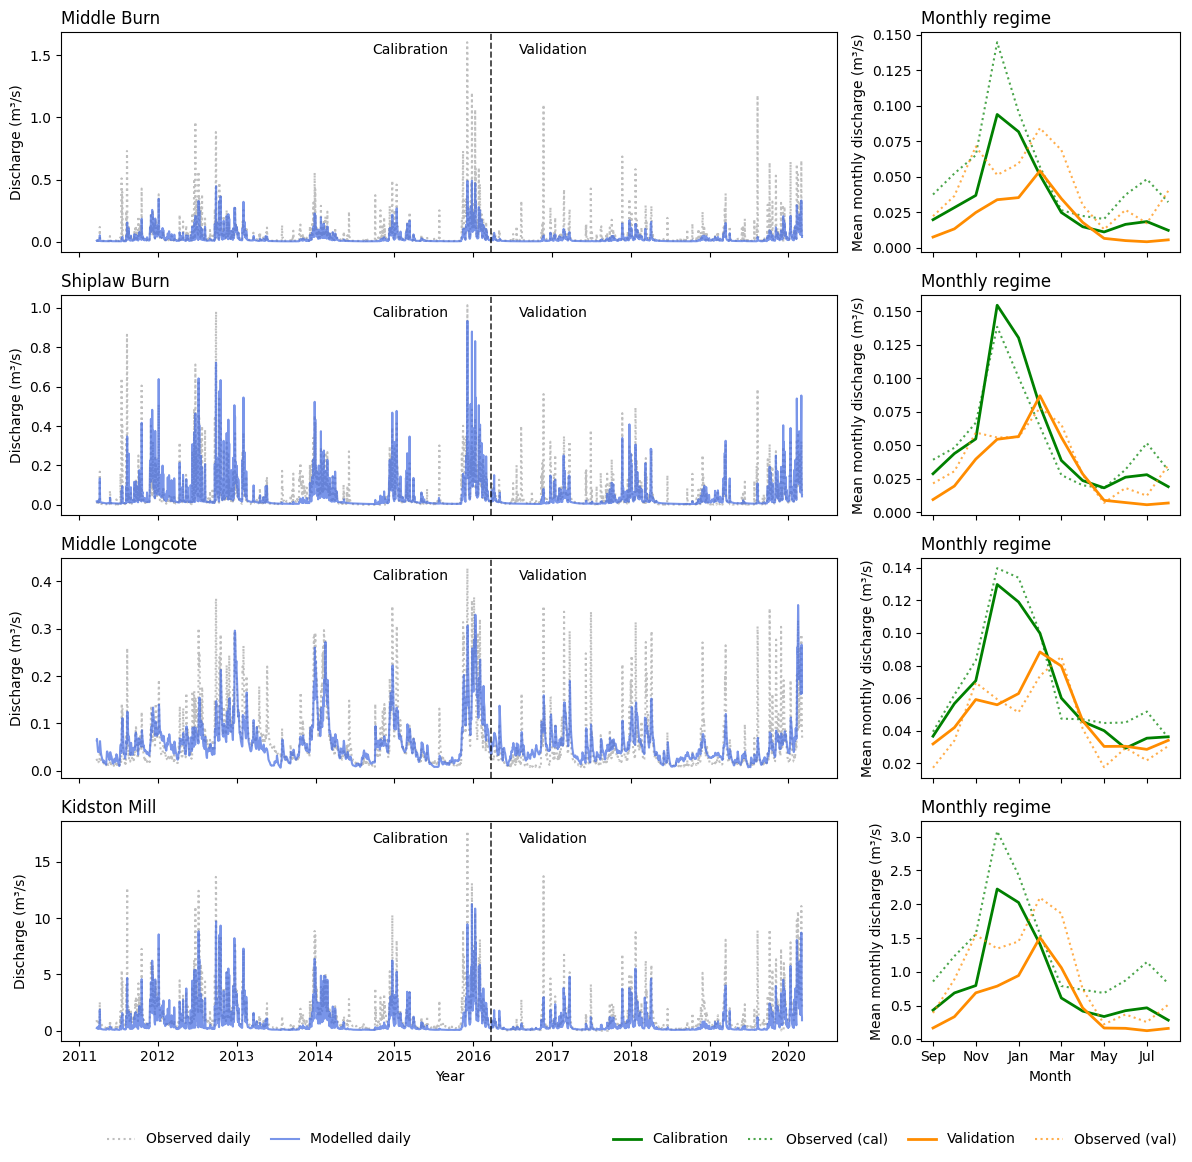

In [ ]:
# Merge panels for cal and val timeseries and regimes

fig, axes = plt.subplots(
    4, 2,
    figsize=(12, 12),
    gridspec_kw={"width_ratios": [3, 1]},
    sharex='col')

axes = axes.reshape(4, 2)

gauges = ["Middle_Burn", "Shiplaw_Burn", "Middle_Longcote", "Kidston_Mill"]
month_names = ["Sep","Oct","Nov","Dec","Jan","Feb","Mar","Apr","May","Jun","Jul","Aug"]
month_order = [9, 10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8]  # September to August (aka hydrological year)

regimes = []
for gauge in gauges:
    regime_df = pd.DataFrame({
        "Observed (cal)": obs_cal.groupby(obs_cal.index.month)[gauge].mean(),
        "Observed (val)": obs_val.groupby(obs_val.index.month)[gauge].mean(),
        "Model (cal)": calibration.groupby(calibration.index.month)[gauge].mean(),
        "Model (val)": validation.groupby(validation.index.month)[gauge].mean(),
    })
    regime_df = regime_df.reindex(month_order)
    regime_df.index = month_names
    regimes.append(regime_df)

split_date = pd.to_datetime("2016-03-22")

# Plotting loop
for i, gauge in enumerate(gauges):

    # Left panel (full timeseries)
    ax_ts = axes[i, 0]
    ax_ts.plot(obs.index, obs[gauge], label="Observed daily", linestyle="dotted", color="grey", alpha=0.5)
    ax_ts.plot(full.index, full[gauge], alpha=0.7, label="Modelled daily", color="royalblue")
    ax_ts.axvline(split_date, color="black", linestyle="--", linewidth=1.2, alpha=0.8)
    ax_ts.text(
        0.4,
        0.95,
        "Calibration",
        transform=ax_ts.transAxes,
        fontsize=10,
        ha="left",
        va="top",
        color="black"
    )
    ax_ts.text(
        0.59,
        0.95,
        "Validation",
        transform=ax_ts.transAxes,
        fontsize=10,
        ha="left",
        va="top",
        color="black"
    )
    ax_ts.set_title(gauge.replace("_", " "), loc="left")
    ax_ts.set_ylabel("Discharge (m³/s)")

    # Right panel (monthly regime)
    ax_reg = axes[i, 1]

    # Cal and val styling
    ax_reg.plot(
        regimes[i].index,
        regimes[i]["Model (cal)"],
        color="green",
        linewidth=2,
        label="Calibration"
    )
    ax_reg.plot(
        regimes[i].index,
        regimes[i]["Observed (cal)"],
        color="green",
        alpha=0.7,
        linestyle="dotted",
        linewidth=1.5,
        label="Observed (cal)"
    )
    ax_reg.plot(
        regimes[i].index,
        regimes[i]["Model (val)"],
        color="darkorange",
        linewidth=2,
        label="Validation"
    )
    ax_reg.plot(
        regimes[i].index,
        regimes[i]["Observed (val)"],
        color="darkorange",
        alpha=0.7,
        linestyle="dotted",
        linewidth=1.5,
        label="Observed (val)"
    )

    ax_reg.set_title("Monthly regime", loc="left")
    ax_reg.set_ylabel("Mean monthly discharge (m³/s)")
    ax_reg.grid(False)


# Yearly ticks on the timeseries plots
for i in range(4):
    ax = axes[i, 0]
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(ticker.NullLocator())

# Monthly ticks on the monthly regimes
tick_labels = ["Sep", "Nov", "Jan", "Mar", "May", "Jul"]
for i in range(4):
    ax = axes[i, 1]
    ax.set_xticks([0, 2, 4, 6, 8, 10])
    ax.set_xticklabels(tick_labels)
    ax.xaxis.set_minor_locator(ticker.NullLocator())

# x-axis labels (bottom plots only)
axes[3, 0].set_xlabel("Year")
axes[3, 1].set_xlabel("Month")

# Remove legends from individual subplots
for row in axes:
    for ax in row:
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()

# Timeseries legend
left_handles, left_labels = [], []
for ax in [axes[0, 0]]:
    handles, labels = ax.get_legend_handles_labels()
    left_handles.extend(handles)
    left_labels.extend(labels)

fig.legend(
    left_handles,
    left_labels,
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(0.22, 0.03),
    frameon=False,
    columnspacing=1.5,
    handlelength=2.0,
)

# Monthly regime legend
right_handles, right_labels = [], []
for ax in [axes[0, 1]]:
    handles, labels = ax.get_legend_handles_labels()
    right_handles.extend(handles)
    right_labels.extend(labels)

fig.legend(
    right_handles,
    right_labels,
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.75, 0.03),
    frameon=False,
    columnspacing=1.4,
    handlelength=2.0,
)

plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.savefig("../Results/Figure34.png", dpi=400, bbox_inches='tight')
plt.show()


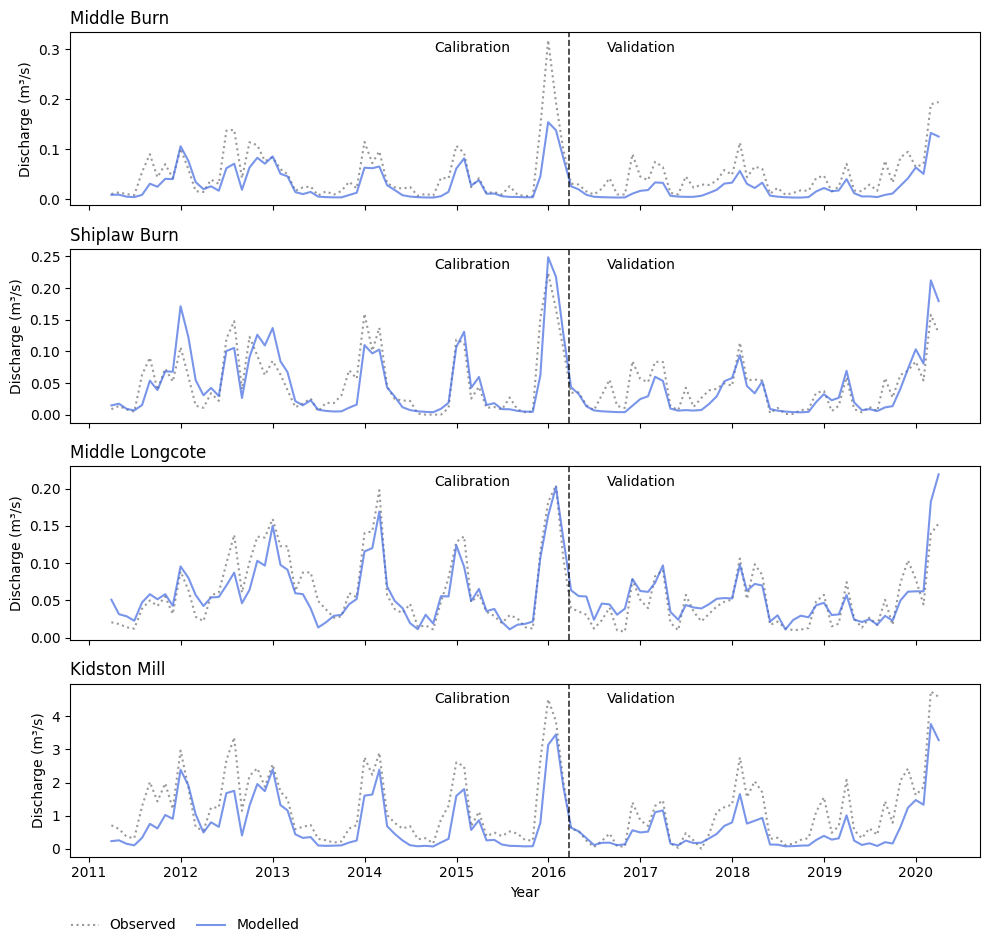

In [ ]:
# Timeseries of monthly discharge

fig, axes = plt.subplots(
    4, 1,
    figsize=(10, 10),
    sharex=True
)

gauges = ["Middle_Burn", "Shiplaw_Burn", "Middle_Longcote", "Kidston_Mill"]
split_date = pd.to_datetime("2016-03-22")

for i, gauge in enumerate(gauges):
    ax = axes[i]

    ax.plot(
        observations_monthly.index,
        observations_monthly[gauge],
        label="Observed",
        linestyle="dotted",
        color="grey",
        alpha=0.8
    )
    ax.plot(
        calandval_monthly.index,
        calandval_monthly[gauge],
        alpha=0.7,
        label="Modelled",
        color="royalblue"
    )
    ax.axvline(split_date, color="black", linestyle="--", linewidth=1.2, alpha=0.8)
    ax.text(
        0.4,
        0.95,
        "Calibration",
        transform=ax.transAxes,
        fontsize=10,
        ha="left",
        va="top",
        color="black"
    )
    ax.text(
        0.59,
        0.95,
        "Validation",
        transform=ax.transAxes,
        fontsize=10,
        ha="left",
        va="top",
        color="black"
    )
    ax.set_title(gauge.replace("_", " "), loc="left")
    ax.set_ylabel("Discharge (m³/s)")

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(ticker.NullLocator())

axes[-1].set_xlabel("Year")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(0.19, 0.05),
    frameon=False,
    columnspacing=1.5,
    handlelength=2.0,
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig("../Results/Figure35.png", dpi=400, bbox_inches='tight')

plt.show()
